In [1]:
from model_ranking import (
    load_h5,
    get_roi_slice,
    get_unique_colourmap,
    get_random_colors,
    save_h5,
)
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
from pytorch3dunet.augment.transforms import Relabel

INFO: P [MainThread] 2025-10-08 09:22:43,531 plantseg - Logger configured at initialisation. PlantSeg logger name: plantseg


/g/kreshuk/talks/miniforge3/envs/model-rank-local2/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/g/kreshuk/talks/pytorch-3dunet/pytorch3dunet/unet3d/predictor.py:22: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [2]:
Fw_gt_path = "/scratch/talks/data/FlyWing/GT/test/per03.h5"
label_key = "volumes/labels/expanded_cells_with_ignore"
raw_key = "volumes/raw"

fw_gt = load_h5(Fw_gt_path, label_key)
fw_raw = load_h5(Fw_gt_path, raw_key)
print(fw_gt.shape, fw_raw.shape)

(160, 639, 765) (160, 639, 765)


# Ov_model_UNet1

In [44]:
pred_path_NA = "/g/kreshuk/talks/consistency_results/Instance_segmentation/Cells/Ovules_to_FlyWing_gap/consistency/P_full/ov_model_UNet1/norm_50_950/none/predictions/per03_predictions.h5"
preds_NA = load_h5(pred_path_NA, "predictions")
segs_NA = load_h5(pred_path_NA, "segmentation")
MAP_score_NA = load_h5(pred_path_NA, "MAP_05_095")
patch_indexes = load_h5(pred_path_NA, "patch_index")
print(preds_NA.shape, MAP_score_NA.shape)

(1440, 1, 1, 256, 256) (1440,)


In [45]:
patchwise_gt = np.zeros_like(preds_NA.squeeze(), dtype=np.int16)
for i in range(patch_indexes.shape[0]):
    sl = get_roi_slice(patch_indexes[i])
    patchwise_gt[i] = fw_gt[sl].squeeze()

In [46]:
patchwise_raw = np.zeros_like(preds_NA.squeeze(), dtype=np.float32)
for i in range(patch_indexes.shape[0]):
    sl = get_roi_slice(patch_indexes[i])
    patchwise_raw[i] = fw_raw[sl].squeeze()

In [47]:
patchwise_gt.shape

(1440, 256, 256)

In [55]:
np.unique(patchwise_gt[0])

array([ -1,   6,   9,  14,  18,  19,  31,  33,  36,  42,  47,  54,  55,
        63,  76,  77,  78,  83,  91, 104, 119, 125, 139, 140, 142, 144,
       147, 159, 168, 173, 189, 197, 198, 199, 205, 210, 211, 231, 250,
       252, 260, 264, 266, 279, 281, 282, 283], dtype=int16)

In [58]:
all_object_counts = []
for i in range(2):#patchwise_gt.shape[0]):
    unique, counts = np.unique(patchwise_gt[i], return_counts=True)
    # Remove -1 from unique and counts if it exists
    if -1 in unique:
        mask = unique != -1
        unique = unique[mask]
        counts = counts[mask]
    all_object_counts.extend(counts)

overall_median = np.median(all_object_counts)
overall_max_obj_size = np.max(all_object_counts)
print(overall_max_obj_size)
print(overall_median)

3303
651.5


In [59]:
651.5*4

2606.0

In [ ]:
# save_path = "/scratch/talks/data/FlyWing/GT/test/per03_patched.h5"
# save_h5(save_path, "label", patchwise_gt, overwrite=True)

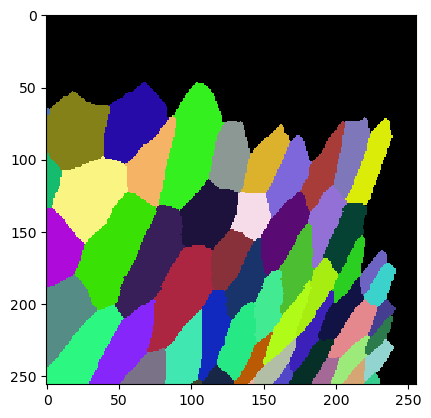

In [34]:
patch_gt = Relabel(ignore_label=-1, append_original=True)(patchwise_gt[110]) 
plt.imshow(patch_gt[0], cmap=get_random_colors(patch_gt[0]), interpolation="nearest")
plt.show()

In [4]:
print(np.median(MAP_score_NA))

0.72135353


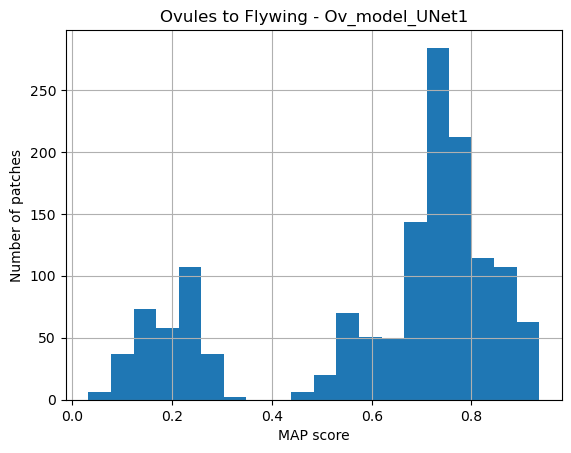

In [5]:
plt.hist(MAP_score_NA, bins=20)
plt.xlabel("MAP score")
plt.ylabel("Number of patches")
plt.title("Ovules to Flywing - Ov_model_UNet1")
plt.grid()
plt.show()

In [6]:
ids_sub_04 = np.where(MAP_score_NA < 0.4)[0]
print(len(ids_sub_04))

320


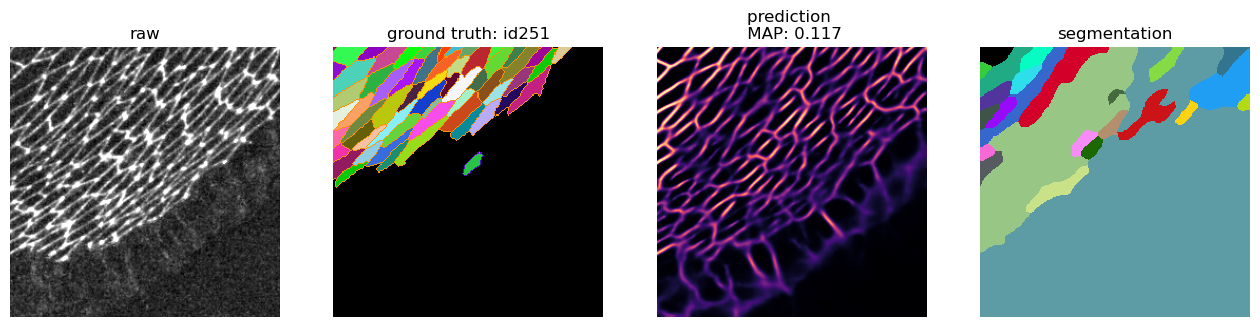

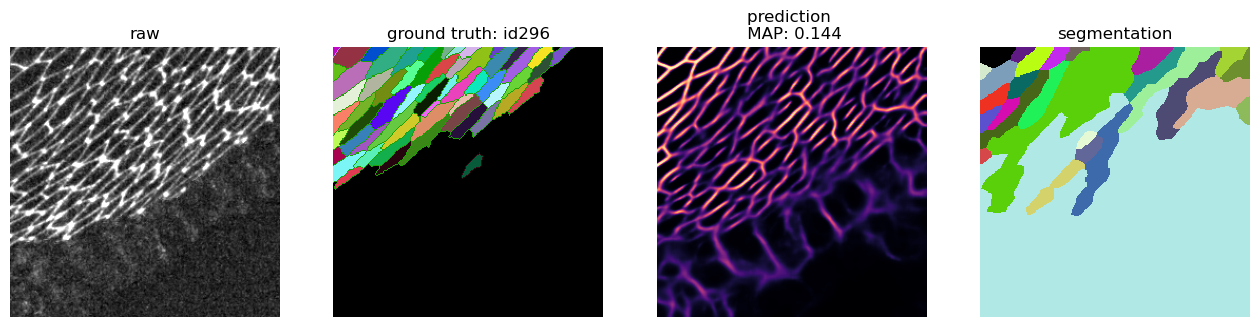

In [15]:
num_samples = 2
selected_augs = ["a001-002", "a002-003", "a003-004", "a004-005", "a005-006"]
rng = np.random.default_rng(42)
rng.shuffle(ids_sub_04)

for i in ids_sub_04[:num_samples]:
    patch_roi = get_roi_slice(patch_indexes[i])
    raw = fw_raw[patch_roi].squeeze()
    label = fw_gt[patch_roi].squeeze()
    label = Relabel(append_original = True, ignore_label=-1)(label)
    #_, axs = plt.subplots(2,4, figsize=(16,8))
    _, axs = plt.subplots(1,4, figsize=(16,4))
    axs = axs.flatten()
    axs[0].imshow(raw, cmap='gray')
    axs[0].set_title("raw")
    axs[0].axis('off')
    axs[1].imshow(label[0], cmap=get_random_colors(label[0]), interpolation='nearest')
    axs[1].set_title(f"ground truth: id{i}")
    axs[1].axis('off')
    axs[2].imshow(preds_NA[i].squeeze(), cmap='magma')
    #axs[2].set_title(f"No TTA prediction \n mSA: {eval_scores[i,0]:.3f}")
    axs[2].set_title(f"prediction \n MAP: {MAP_score_NA[i]:.3f}")
    axs[2].axis('off')
    axs[3].imshow(segs_NA[i].squeeze(), cmap=get_random_colors(segs_NA[i]), interpolation='nearest')
    axs[3].set_title(f"segmentation")
    axs[3].axis('off')
    plt.show()

# fw_model_Unetr2

In [16]:
pred_path_NA = "/g/kreshuk/talks/consistency_results/Instance_segmentation/Cells/FlyWing_to_FlyWing_gap/consistency/P_full/fw_model_Unetr2/norm_50_950/none/predictions/per03_predictions.h5"
preds_NA = load_h5(pred_path_NA, "predictions")
segs_NA = load_h5(pred_path_NA, "segmentation")
MAP_score_NA = load_h5(pred_path_NA, "MAP_05_095")
patch_indexes = load_h5(pred_path_NA, "patch_index")
print(preds_NA.shape, MAP_score_NA.shape)

(1440, 1, 1, 256, 256) (1440,)


In [3]:
base_path = "/g/kreshuk/talks/consistency_results/Instance_segmentation/Cells/FlyWing_to_FlyWing_gap/consistency/P_full/fw_model_Unetr2/norm_50_950"
paths = list(Path(base_path).rglob("**/predictions/per03_predictions.h5"))

In [5]:
paths

[PosixPath('/g/kreshuk/talks/consistency_results/Instance_segmentation/Cells/FlyWing_to_FlyWing_gap/consistency/P_full/fw_model_Unetr2/norm_50_950/none/predictions/per03_predictions.h5'),
 PosixPath('/g/kreshuk/talks/consistency_results/Instance_segmentation/Cells/FlyWing_to_FlyWing_gap/consistency/P_full/fw_model_Unetr2/norm_50_950/gauss_a001-003/predictions/per03_predictions.h5'),
 PosixPath('/g/kreshuk/talks/consistency_results/Instance_segmentation/Cells/FlyWing_to_FlyWing_gap/consistency/P_full/fw_model_Unetr2/norm_50_950/gauss_a003-005/predictions/per03_predictions.h5'),
 PosixPath('/g/kreshuk/talks/consistency_results/Instance_segmentation/Cells/FlyWing_to_FlyWing_gap/consistency/P_full/fw_model_Unetr2/norm_50_950/gauss_a005-007/predictions/per03_predictions.h5'),
 PosixPath('/g/kreshuk/talks/consistency_results/Instance_segmentation/Cells/FlyWing_to_FlyWing_gap/consistency/P_full/fw_model_Unetr2/norm_50_950/gauss_a007-01/predictions/per03_predictions.h5'),
 PosixPath('/g/kreshu

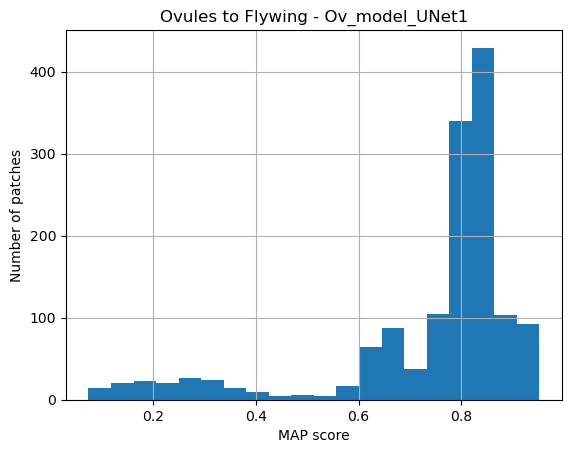

In [17]:
plt.hist(MAP_score_NA, bins=20)
plt.xlabel("MAP score")
plt.ylabel("Number of patches")
plt.title("Ovules to Flywing - Ov_model_UNet1")
plt.grid()
plt.show()

In [18]:
ids_sub_04 = np.where(MAP_score_NA < 0.4)[0]
print(len(ids_sub_04))

144


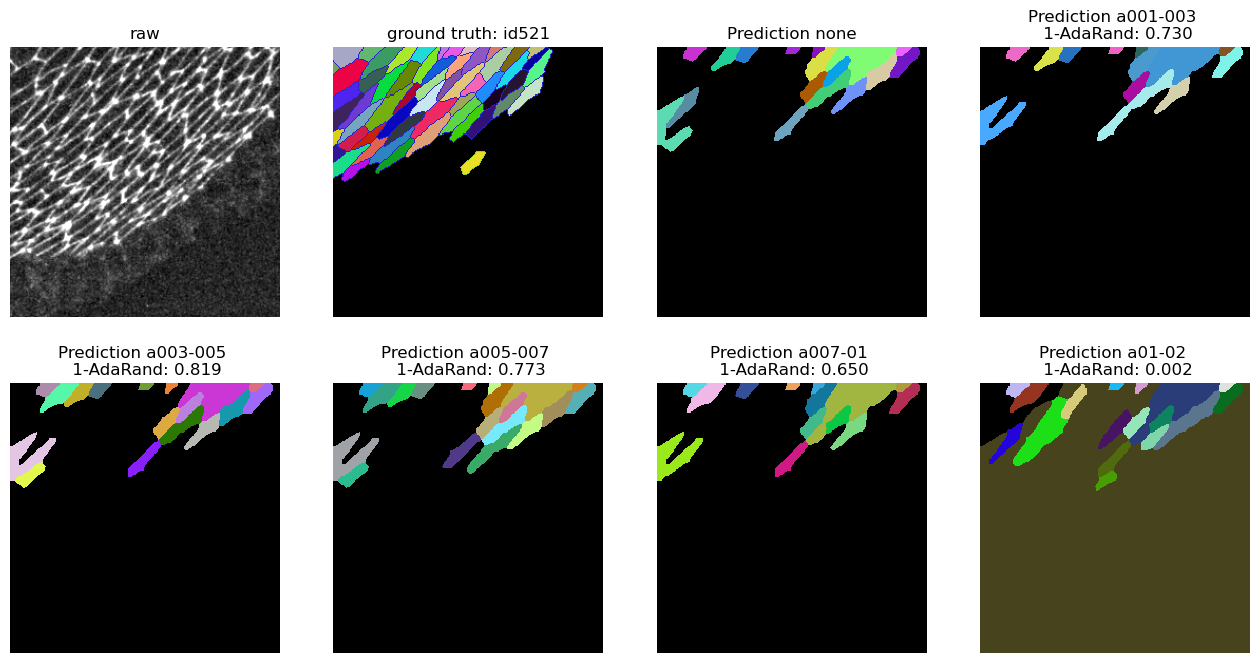

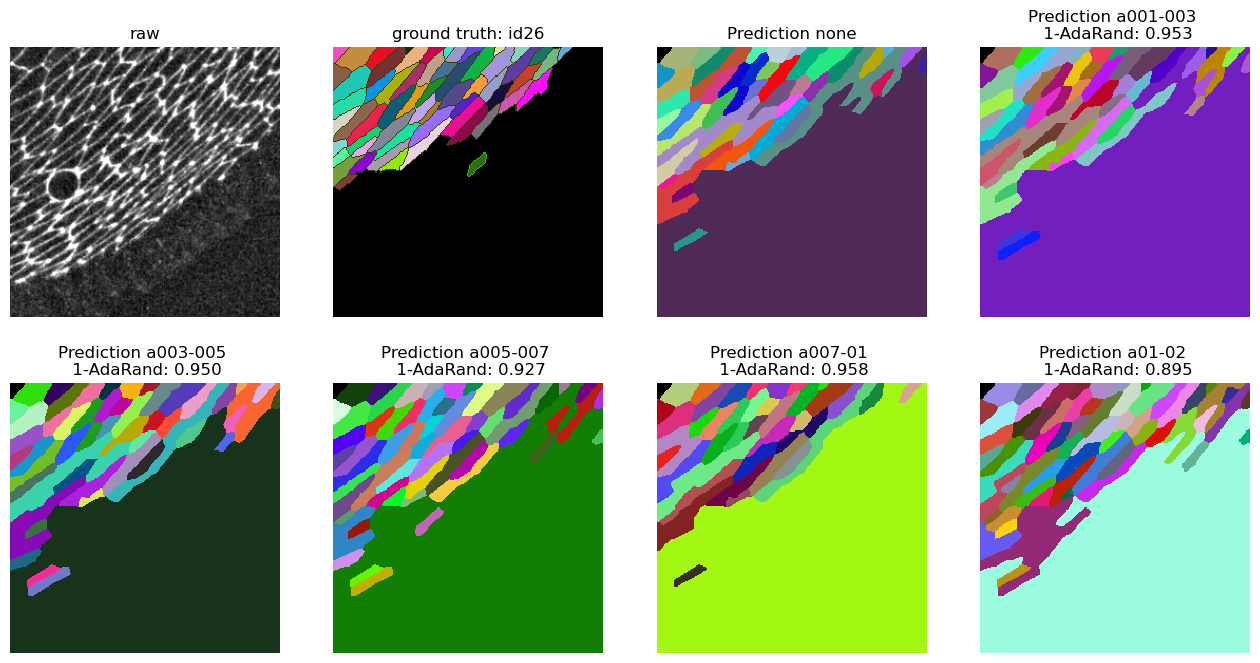

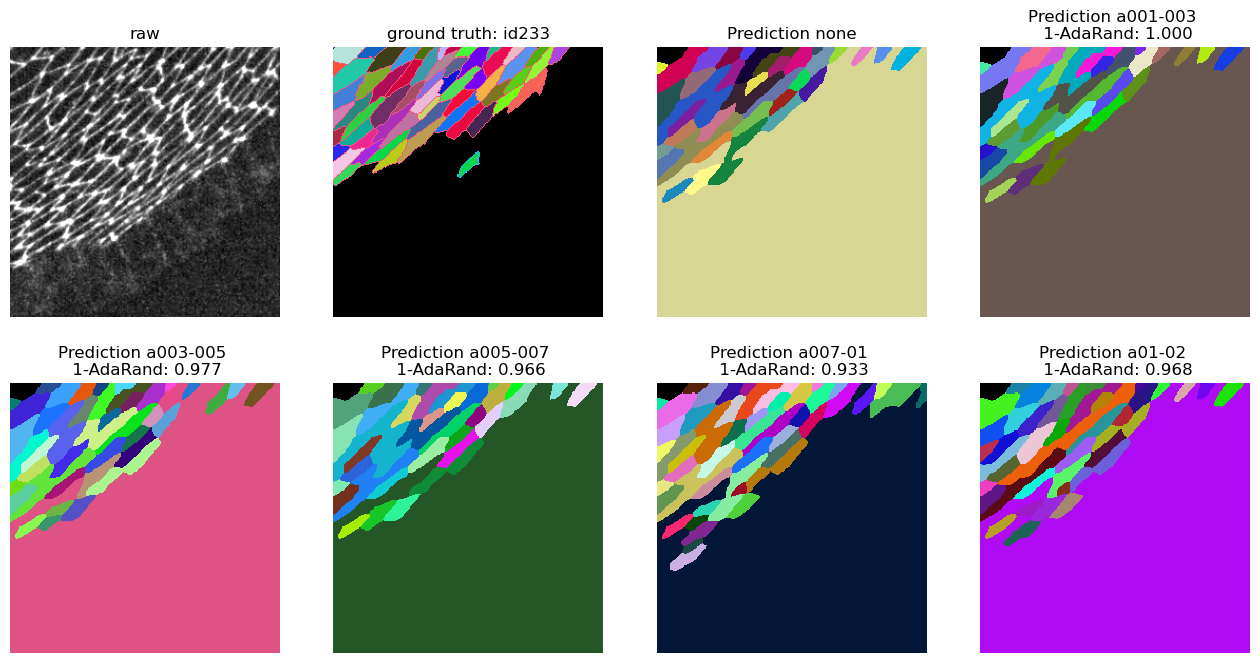

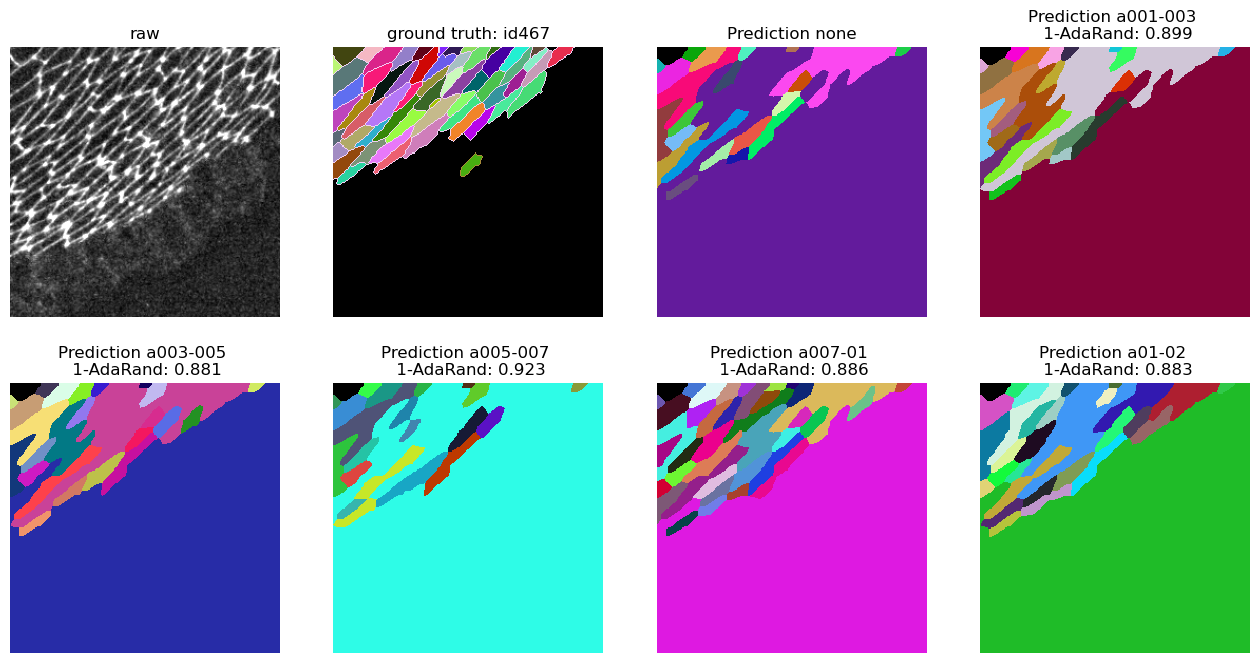

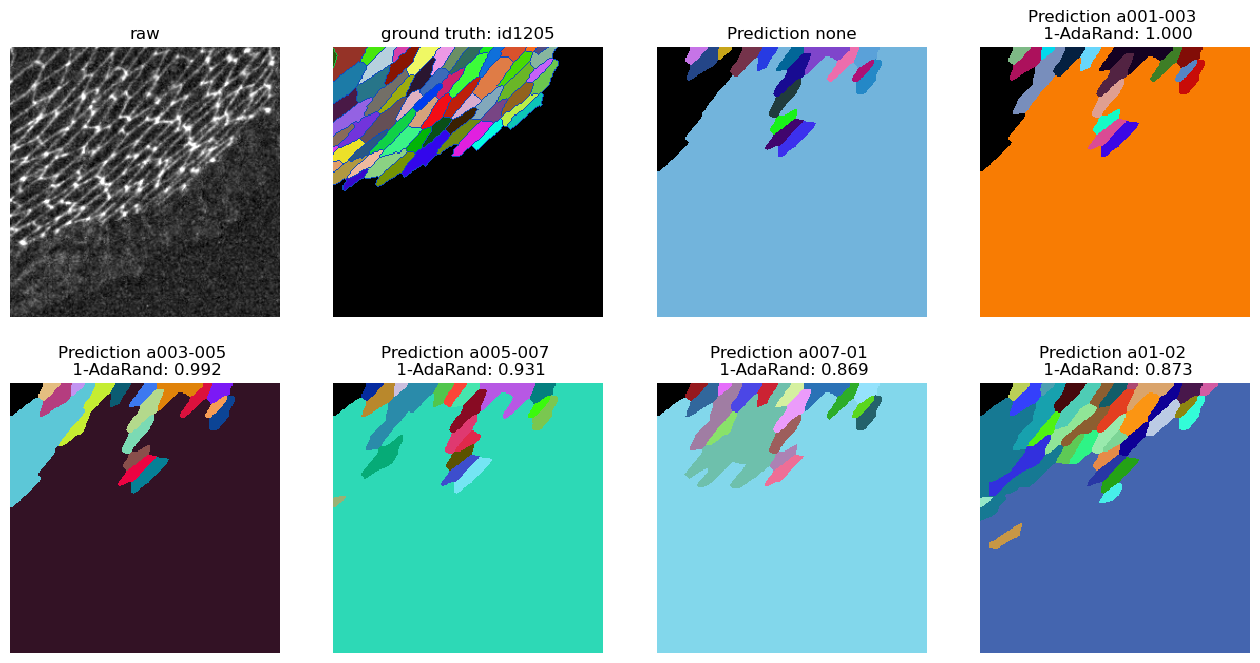

In [42]:
num_samples = 5
selected_augs = ["none", "a001-003", 'a003-005', 'a005-007', 'a007-01', 'a01-02']
rng = np.random.default_rng(42)
rng.shuffle(ids_sub_04)

for i in ids_sub_04[:num_samples]:
    patch_roi = get_roi_slice(patch_indexes[i])
    raw = fw_raw[patch_roi].squeeze()
    label = fw_gt[patch_roi].squeeze()
    label = Relabel(append_original = True, ignore_label=-1)(label)
    _, axs = plt.subplots(2,4, figsize=(16,8))
    axs = axs.flatten()
    axs[0].imshow(raw, cmap='gray')
    axs[0].set_title("raw")
    axs[0].axis('off')
    axs[1].imshow(label[0], cmap=get_random_colors(label[0]), interpolation='nearest')
    axs[1].set_title(f"ground truth: id{i}")
    axs[1].axis('off')
    # axs[2].imshow(load_h5(pred_path_NA, "segmentation", select_index=i).squeeze(), cmap='magma')
    # axs[2].set_title(f"Segmentation NA \n MAP: {MAP_score_NA[i]:.3f}")
    # axs[2].axis('off')
    for j, path in enumerate(paths):
        assert selected_augs[j] in str(path)
        preds_temp = load_h5(path, "segmentation", select_index=i)
        axs[2+j].imshow(preds_temp.squeeze(), cmap=get_random_colors(preds_temp), interpolation='nearest')
        if "none" not in str(path):
            AdaRand_score = 1 - load_h5(path, "AdaRandError_consis", select_index=i)[0]
            axs[2+j].set_title(f"Prediction {selected_augs[j]} \n 1-AdaRand: {AdaRand_score:.3f}")
        else:
            axs[2+j].set_title(f"Prediction {selected_augs[j]}")
        axs[2+j].axis('off')
    plt.show()

In [4]:
id = 1205
print(paths[0])

/g/kreshuk/talks/consistency_results/Instance_segmentation/Cells/FlyWing_to_FlyWing_gap/consistency/P_full/fw_model_Unetr2/norm_50_950/none/predictions/per03_predictions.h5


In [5]:
preds = load_h5(paths[0], "predictions", select_index=[id])
segs = load_h5(paths[0], "segmentation", select_index=[id])
MAP_score = load_h5(paths[0], "MAP_05_095", select_index=[id])
patch_index = load_h5(paths[0], "patch_index", select_index=[id])

In [6]:
patch_index[0]

array([[133, 134],
       [383, 639],
       [509, 765]])

In [7]:
raw = load_h5(Fw_gt_path, raw_key, roi=patch_index[0])
label = load_h5(Fw_gt_path, label_key, roi=patch_index[0])
label = Relabel(ignore_label=-1, append_original=True)(label)[0]

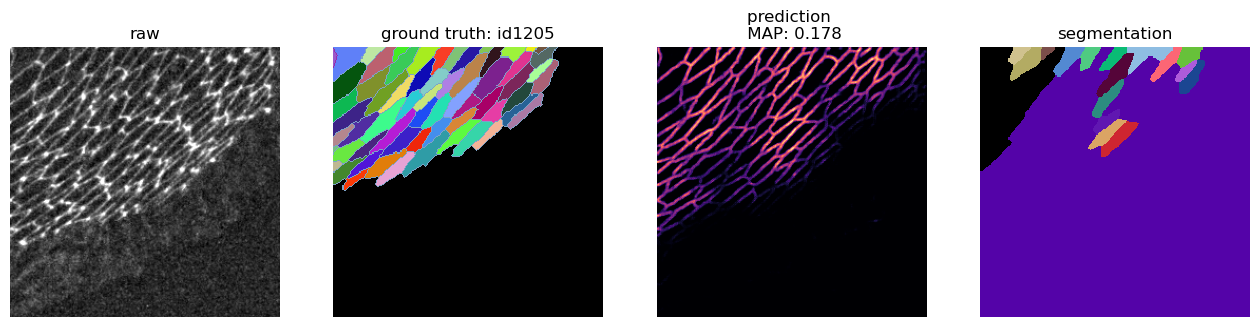

In [8]:
_, axs = plt.subplots(1,4, figsize=(16,4))
axs = axs.flatten()
axs[0].imshow(raw.squeeze(), cmap='gray')
axs[0].set_title("raw")
axs[0].axis('off')
axs[1].imshow(label.squeeze(), cmap=get_random_colors(label), interpolation='nearest')
axs[1].set_title(f"ground truth: id{id}")
axs[1].axis('off')
axs[2].imshow(preds.squeeze(), cmap='magma')
axs[2].set_title(f"prediction \n MAP: {MAP_score[0]:.3f}")
axs[2].axis('off')
axs[3].imshow(segs.squeeze(), cmap=get_random_colors(segs), interpolation='nearest')
axs[3].set_title(f"segmentation")
axs[3].axis('off')
plt.show()

In [3]:
from pytorch3dunet.unet3d.utils import zero_large_instances
from pytorch3dunet.unet3d.predictor import pmaps_to_IN_seg
from plantseg.functionals.dataprocessing.labelprocessing import set_background_to_value, set_biggest_instance_to_zero, relabel_segmentation
from plantseg.functionals.segmentation import dt_watershed, gasp
from plantseg.functionals.dataprocessing import set_background_to_value


In [10]:
preds.shape

(1, 1, 1, 256, 256)

In [11]:
a = np.full((10, 10), 1)
a[0,0] = 2
a[0,1] = 10
a[0,2] = 3
b = Relabel()(a)
c = relabel_segmentation(a)
print(np.unique(c))
print(np.unique(b))

[1 2 3 4]
[0 1 2 3]


[  2   3   4   5   6   7   8   9  10  11  12  13  14  17  18  19  20  21
  22  23  24  25  27  28  30  31  32  33  34  35  36  37  38  40  41  42
  43  44  45  46  47  48  49  50  51  52  54  58  59  60  61  62  63  64
  66  67  68  69  70  71  72  73  74  75  76  77  78  79  80  81  82  83
  84  85  86  87  90  92  93  94  95  96  97  98  99 100 101 102 103 104
 105 106]
[  2   3   4   5   6   7   8   9  10  11  12  13  14  17  18  19  20  21
  22  23  24  25  27  28  30  31  32  33  34  35  36  37  38  40  41  42
  43  44  45  46  47  48  49  50  51  52  54  58  59  60  61  62  63  64
  66  67  68  69  70  71  72  73  74  75  76  77  78  79  80  81  82  83
  84  85  86  87  90  92  93  94  95  96  97  98  99 100 101 102 103 104
 105 106]
[  2   3   4   5   7   8   9  17  20  21  24  25  28  30  32  34  35  37
  40  41  45  46  48  49  51  58  59  60  61  63  66  67  68  71  73  76
  79  82  83  85  87  90  93  95  96  97  98  99 102 103 105]


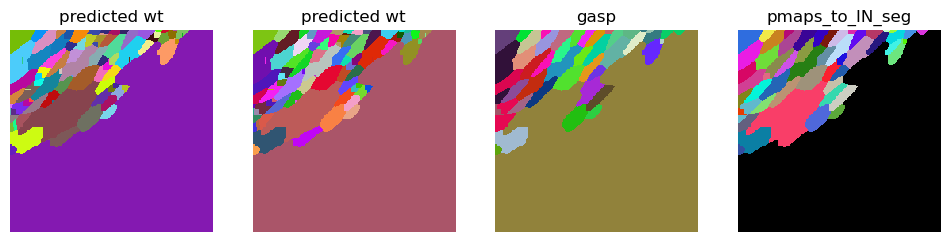

In [19]:
_, axs = plt.subplots(1,4, figsize=(12,4))
axs = axs.flatten()
seg = pmaps_to_IN_seg(preds[0,0], min_size=20, beta=0.8, zero_largest_instance=True)
pred_wt = dt_watershed(preds[0,0], stacked=True, min_size=5)
#pred_wt = set_biggest_instance_to_zero(pred_wt)
axs[0].imshow(pred_wt.squeeze(), cmap=get_random_colors(pred_wt), interpolation='nearest')
axs[0].set_title("predicted wt")
axs[0].axis('off')
print(np.unique(pred_wt))
#pred_wt = set_biggest_instance_to_zero(pred_wt, instance_could_be_zero=True)
print(np.unique(pred_wt))
gasp_pred = gasp(preds[0,0], pred_wt, post_minsize=5, beta=0.7)
print(np.unique(gasp_pred))

axs[1].imshow(pred_wt.squeeze(), cmap=get_random_colors(pred_wt), interpolation='nearest')
axs[1].set_title("predicted wt")
axs[1].axis('off')
axs[2].imshow(gasp_pred.squeeze(), cmap=get_random_colors(gasp_pred), interpolation='nearest')
axs[2].set_title("gasp")
axs[2].axis('off')
axs[3].imshow(seg.squeeze(), cmap=get_random_colors(seg), interpolation='nearest')
axs[3].set_title("pmaps_to_IN_seg")
axs[3].axis('off')
plt.show()


In [53]:
np.unique(gasp_pred)

array([  1,   3,  21,  23,  36,  42,  64,  66,  75,  76,  77,  78,  82,
        83,  89,  92, 100, 102], dtype=uint32)

In [15]:
seg_remove_instance = zero_large_instances(segs.squeeze())
print(seg_remove_instance.shape)

(256, 256)


In [29]:
print(segs.shape)

(1, 1, 1, 256, 256)


(256, 256)


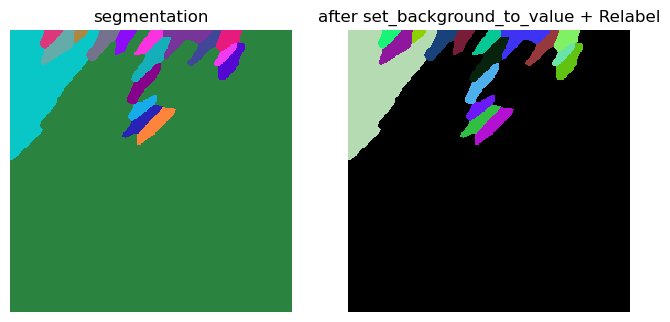

In [41]:
pred = set_biggest_instance_to_zero(segs[0,0])
pred = Relabel()(pred[0])  # pyright: ignore[reportUnknownVariableType]
print(pred.shape)

_, axs = plt.subplots(1,2, figsize=(8,4))
axs = axs.flatten()
axs[0].imshow(segs.squeeze(), cmap=get_random_colors(segs), interpolation='nearest')
axs[0].set_title("segmentation")
axs[0].axis('off')
axs[1].imshow(pred.squeeze(), cmap=get_random_colors(pred), interpolation='nearest')
axs[1].set_title("after set_background_to_value + Relabel")
axs[1].axis('off')
plt.show()

In [34]:
np.unique(segs)

array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18], dtype=uint16)

In [ ]:
pred = set_background_to_value(segs[0,0], 0)
pred = Relabel()(pred[0])  # pyright: ignore[reportUnknownVariableType]
print(np.unique(pred))

[ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18]


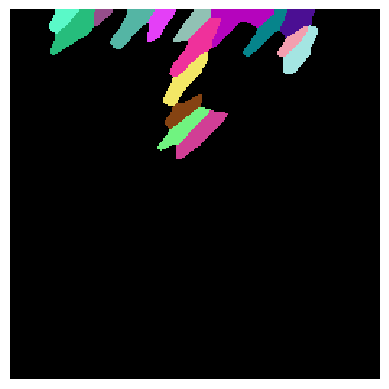

In [16]:
plt.imshow(seg_remove_instance, cmap=get_random_colors(seg_remove_instance), interpolation='nearest')
plt.axis('off')
plt.show()

In [65]:
from model_ranking import (
    FlyWingTargetConfig,
    StandardEvalDataset,
)

In [101]:
dataset = StandardEvalDataset(
    pred_path="/g/kreshuk/talks/consistency_results/Instance_segmentation/Cells/FlyWing_to_FlyWing_gap/consistency/P_full/fw_model_Unetr2/norm_50_950/none/predictions/per03_predictions.h5",
    gt_path="/scratch/talks/data/FlyWing/GT/test/per03.h5",
    pred_key="segmentation",
    gt_key="volumes/labels/cells_with_ignore",
    roi=None,
    patch_key="patch_index",
    ignore_index=-1,
    convert_to_boundary_label=False,
    convert_to_binary_label=False,
    min_object_size=50,
    gt_zero_largest_instance=False,
    zero_large_instances=False,
    zero_largest_instance=True,
)
print(len(dataset))

1440


In [102]:
pred, gt = dataset[1205]
print(pred.shape, gt.shape)
print(type(pred), type(gt))

(1, 1, 256, 256) (1, 1, 256, 256)
<class 'numpy.ndarray'> <class 'numpy.ndarray'>


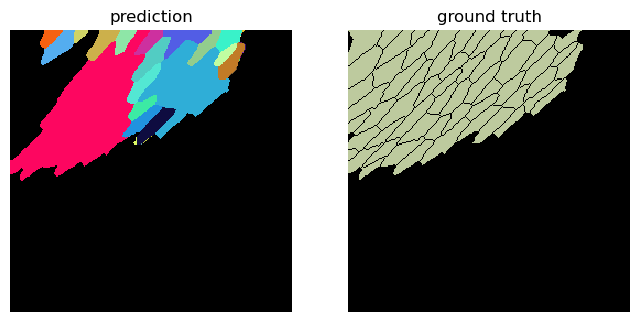

In [103]:
_, axs = plt.subplots(1,2, figsize=(8,4))
axs = axs.flatten()
axs[0].imshow(pred.squeeze(), cmap=get_random_colors(pred), interpolation='nearest')
axs[0].set_title("prediction")
axs[0].axis('off')
axs[1].imshow(gt.squeeze(), cmap=get_random_colors(gt), interpolation='nearest')
axs[1].set_title("ground truth")
axs[1].axis('off')
plt.show()

# FlyWing Unet2

In [7]:
from pytorch3dunet.unet3d.utils import zero_large_instances
from pytorch3dunet.unet3d.predictor import pmaps_to_IN_seg
from plantseg.functionals.dataprocessing.labelprocessing import set_background_to_value, set_biggest_instance_to_zero, relabel_segmentation
from plantseg.functionals.segmentation import dt_watershed, gasp
from plantseg.functionals.dataprocessing import set_background_to_value

In [3]:
path = "/g/kreshuk/talks/consistency_results/Instance_segmentation/Cells/FlyWing_to_FlyWing_gap/consistency/P_full_max_obj_4/fw_model_Unet2/norm_50_950/none/predictions/per03_predictions.h5"

In [4]:
id = 550
seg = load_h5(path, "segmentation", select_index=[id])
pred = load_h5(path, "predictions", select_index=[id])
patch_index = load_h5(path, "patch_index", select_index=[id])[0]
raw = fw_raw[get_roi_slice(patch_index)].squeeze()
gt = fw_gt[get_roi_slice(patch_index)].squeeze()


In [16]:
img = relabel_segmentation(seg[0])
print(np.unique(img))

NotImplementedError: Only for images of dimension 1-3 are supported, got a 4D one

In [8]:
def pmaps_to_IN_seg2(
    pred, 
    min_size,
    zero_largest_instance=False, 
    zero_large_instances=False, 
    beta=0.5, 
    large_instance_multiplier=4,
    max_obj_size=None
):
    if pred.ndim == 2:
        pred = np.expand_dims(pred, axis=0)
    else:
        assert pred.ndim == 3, f"Expected 2D or 3D array, got {pred.ndim}D array"
    pred_wt = dt_watershed(pred, stacked=True, min_size=min_size)
    gasp_pred = gasp(pred, pred_wt, post_minsize=min_size, beta=beta)
    if zero_largest_instance:
        gasp_pred = set_biggest_instance_to_zero(gasp_pred, instance_could_be_zero=True)
        gasp_pred = relabel_segmentation(gasp_pred).squeeze()
    elif zero_large_instances:
        gasp_pred = zero_large_instances(
            gasp_pred, threshold_multiplier=large_instance_multiplier, max_obj_size=max_obj_size).squeeze()
    else:
        gasp_pred = relabel_segmentation(gasp_pred).squeeze()
    
    return gasp_pred

In [14]:
IN_seg = pmaps_to_IN_seg2(pred[0,0], min_size=50, max_obj_size=651.5, zero_large_instances=True)
print(np.unique(IN_seg))

[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47
 48]


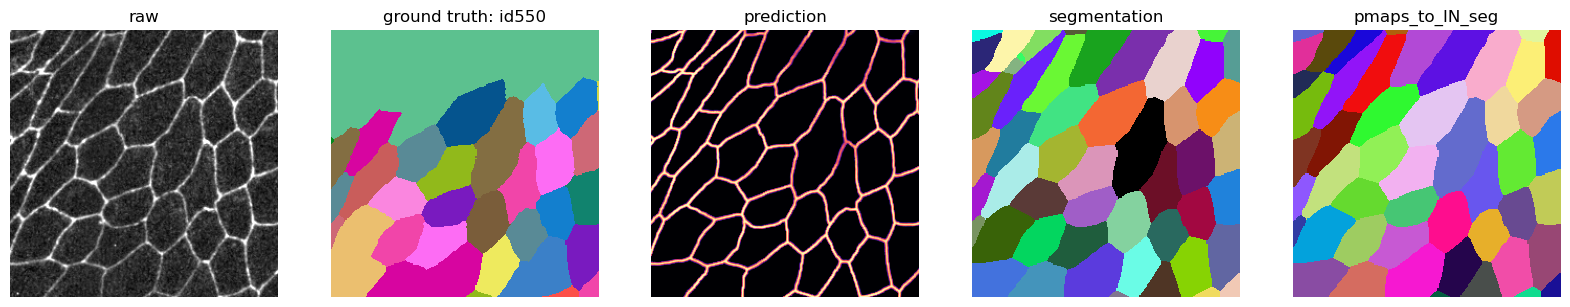

In [85]:
_, axs = plt.subplots(1,5, figsize=(20,4))
axs = axs.flatten()
axs[0].imshow(raw, cmap='gray')
axs[0].set_title("raw")
axs[0].axis('off')
axs[1].imshow(gt, cmap=get_random_colors(gt), interpolation='nearest')
axs[1].set_title(f"ground truth: id{id}")
axs[1].axis('off')
axs[2].imshow(pred.squeeze(), cmap='magma')
axs[2].set_title(f"prediction")
axs[2].axis('off')
axs[3].imshow(seg.squeeze(), cmap=get_random_colors(seg), interpolation='nearest') 
axs[3].set_title(f"segmentation")
axs[3].axis('off')
axs[4].imshow(IN_seg.squeeze(), cmap=get_random_colors(IN_seg), interpolation='nearest')
axs[4].set_title(f"pmaps_to_IN_seg")
axs[4].axis('off')
plt.show()

In [72]:
pred.shape

(1, 1, 1, 256, 256)

In [74]:
IN_seg = pmaps_to_IN_seg(pred[0,0], min_size=50)

In [17]:
from model_ranking import (
    StandardEvalDataset,
)

In [18]:
dataset = StandardEvalDataset(
    pred_path="/g/kreshuk/talks/consistency_results/Instance_segmentation/Cells/FlyWing_to_FlyWing_gap/consistency/P_full_max_obj_2/fw_model_Unet2/norm_50_950/none/predictions/per03_predictions.h5",
    gt_path="/scratch/talks/data/FlyWing/GT/test/per03.h5",
    pred_key="segmentation",
    gt_key="volumes/labels/expanded_cells_with_ignore",
    roi=None,
    patch_key="patch_index",
    ignore_index=-1,
    convert_to_boundary_label=False,
    convert_to_binary_label=False,
    min_object_size=50,
    gt_zero_largest_instance=False,
    zero_large_instances=False,
    zero_largest_instance=False,
)
print(len(dataset))

1440


In [ ]:
_, axs = plt.subplots(20,10, figsize=(15,30))
axs = axs.flatten()
for i in range(200):
    seg, gt = dataset[i]
    axs[i].imshow(seg.squeeze(), cmap=get_random_colors(seg), interpolation='nearest')
    axs[i].axis('off')
plt.tight_layout()
plt.show()


# ov_model_Res1

In [4]:
from pytorch3dunet.unet3d.utils import zero_large_instances
from pytorch3dunet.unet3d.predictor import pmaps_to_IN_seg
from plantseg.functionals.dataprocessing.labelprocessing import set_background_to_value, set_biggest_instance_to_zero, relabel_segmentation
from plantseg.functionals.segmentation import dt_watershed, gasp
from plantseg.functionals.dataprocessing import set_background_to_value

In [6]:
path = "/g/kreshuk/talks/consistency_results/Instance_segmentation/Cells/Ovules_to_FlyWing_gap/consistency/P_full2/ov_model_Res1/norm_50_950/none/predictions/per03_predictions.h5"


In [22]:
MAP_scores = load_h5(path, "MAP_05_095")
segs = load_h5(path, "segmentation")
print(np.median(MAP_scores))
print(len(MAP_scores))

0.012625208
1440


In [26]:
print(segs.shape)
zero_z_indices = []
for z in range(segs.shape[0]):
    if np.all(segs[z] == 0):
        zero_z_indices.append(z)
#print(f"Z indices with all zeros: {zero_z_indices}")
print(f"Number of slices with all zeros: {len(zero_z_indices)}")

(1440, 1, 1, 256, 256)
Number of slices with all zeros: 438


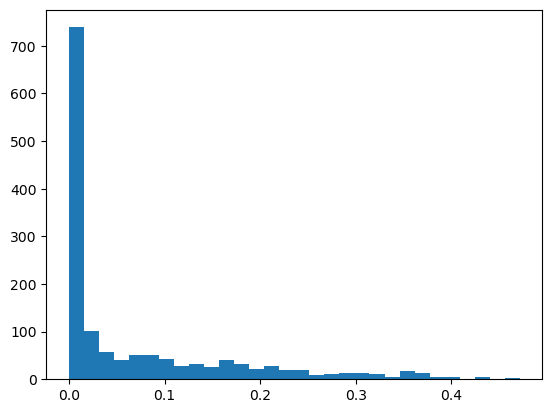

In [21]:
plt.hist(MAP_scores, bins=30)
plt.show()


In [14]:
id = 1162
seg = load_h5(path, "segmentation", select_index=[id])
pred = load_h5(path, "predictions", select_index=[id])
patch_index = load_h5(path, "patch_index", select_index=[id])[0]
raw = fw_raw[get_roi_slice(patch_index)].squeeze()
gt = fw_gt[get_roi_slice(patch_index)].squeeze()

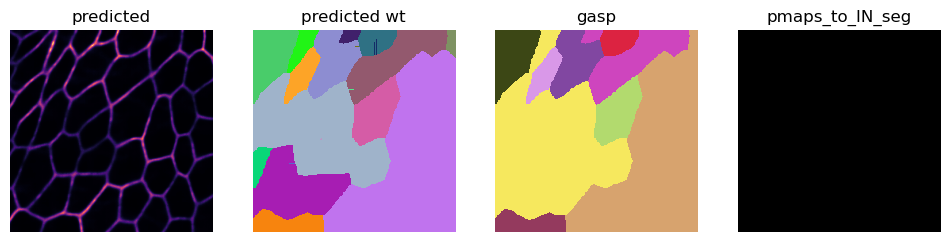

In [ ]:
_, axs = plt.subplots(1,4, figsize=(12,4))
axs = axs.flatten()
seg = pmaps_to_IN_seg(pred[0,0], min_size=20, beta=0.8, zero_largest_instance=True)
pred_wt = dt_watershed(pred[0,0], threshold=0.2, stacked=True, min_size=5)
#pred_wt = set_biggest_instance_to_zero(pred_wt)
axs[0].imshow(pred.squeeze(), cmap='magma')
axs[0].set_title("predicted")
axs[0].axis('off')
#print(np.unique(pred_wt))
#pred_wt = set_biggest_instance_to_zero(pred_wt, instance_could_be_zero=True)
#print(np.unique(pred_wt))
gasp_pred = gasp(pred[0,0], pred_wt, post_minsize=50, beta=0.8)
#print(np.unique(gasp_pred))

axs[1].imshow(pred_wt.squeeze(), cmap=get_random_colors(pred_wt), interpolation='nearest')
axs[1].set_title("predicted wt")
axs[1].axis('off')
axs[2].imshow(gasp_pred.squeeze(), cmap=get_random_colors(gasp_pred), interpolation='nearest')
axs[2].set_title("gasp")
axs[2].axis('off')
axs[3].imshow(seg.squeeze(), cmap=get_random_colors(seg), interpolation='nearest')
axs[3].set_title("pmaps_to_IN_seg")
axs[3].axis('off')
plt.show()


# ov_model_UNet1

In [27]:
path = "/g/kreshuk/talks/consistency_results/Instance_segmentation/Cells/Ovules_to_FlyWing_gap/consistency/P_full2/ov_model_UNet1/norm_50_950/none/predictions/per03_predictions.h5"


In [28]:
MAP_scores = load_h5(path, "MAP_05_095")
segs = load_h5(path, "segmentation")
print(np.median(MAP_scores))
print(len(MAP_scores))

0.5737462
1440


In [29]:
print(segs.shape)
zero_z_indices = []
for z in range(segs.shape[0]):
    if np.all(segs[z] == 0):
        zero_z_indices.append(z)
#print(f"Z indices with all zeros: {zero_z_indices}")
print(f"Number of slices with all zeros: {len(zero_z_indices)}")

(1440, 1, 1, 256, 256)
Number of slices with all zeros: 0


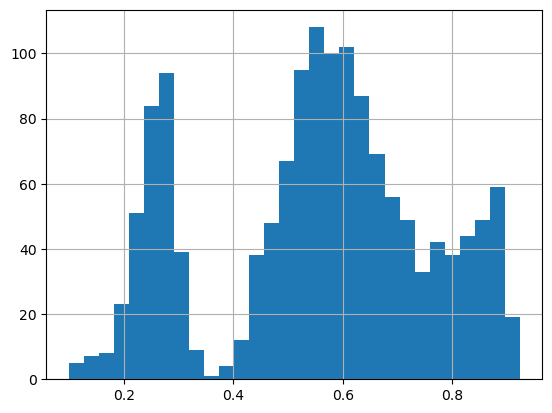

In [31]:
plt.hist(MAP_scores, bins=30)
plt.grid()
plt.show()


In [32]:
ids = np.where(MAP_scores < 0.4)[0]
print(len(ids))

325


In [33]:
id = ids[2]
seg = load_h5(path, "segmentation", select_index=[id])
pred = load_h5(path, "predictions", select_index=[id])
patch_index = load_h5(path, "patch_index", select_index=[id])[0]
raw = fw_raw[get_roi_slice(patch_index)].squeeze()
gt = fw_gt[get_roi_slice(patch_index)].squeeze()

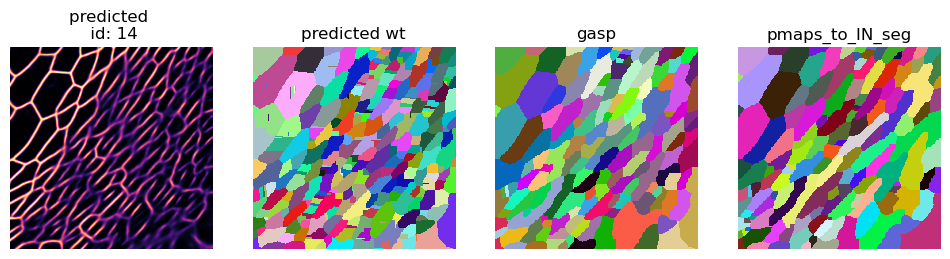

In [36]:
_, axs = plt.subplots(1,4, figsize=(12,4))
axs = axs.flatten()
seg = pmaps_to_IN_seg(pred[0,0], min_size=20, beta=0.8, zero_large_instances=True, max_obj_size=3303)
pred_wt = dt_watershed(pred[0,0], threshold=0.2, stacked=True, min_size=5)
#pred_wt = set_biggest_instance_to_zero(pred_wt)
axs[0].imshow(pred.squeeze(), cmap='magma')
axs[0].set_title("predicted \n id: "+str(id))
axs[0].axis('off')
#print(np.unique(pred_wt))
#pred_wt = set_biggest_instance_to_zero(pred_wt, instance_could_be_zero=True)
#print(np.unique(pred_wt))
gasp_pred = gasp(pred[0,0], pred_wt, post_minsize=50, beta=0.8)
#print(np.unique(gasp_pred))

axs[1].imshow(pred_wt.squeeze(), cmap=get_random_colors(pred_wt), interpolation='nearest')
axs[1].set_title("predicted wt")
axs[1].axis('off')
axs[2].imshow(gasp_pred.squeeze(), cmap=get_random_colors(gasp_pred), interpolation='nearest')
axs[2].set_title("gasp")
axs[2].axis('off')
axs[3].imshow(seg.squeeze(), cmap=get_random_colors(seg), interpolation='nearest')
axs[3].set_title("pmaps_to_IN_seg")
axs[3].axis('off')
plt.show()


# p_model_NA1

In [37]:
path = "/g/kreshuk/talks/consistency_results/Instance_segmentation/Cells/PNAS_to_FlyWing_gap/consistency/P_full2/p_model_NA1/norm_50_950/none/predictions/per03_predictions.h5"

0.54704475
1440


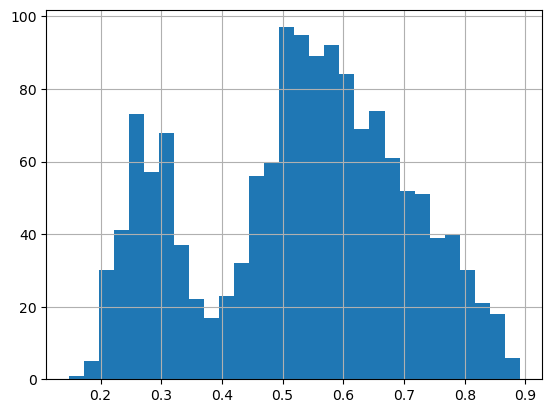

In [40]:
MAP_scores = load_h5(path, "MAP_05_095")
segs = load_h5(path, "segmentation")
patch_indexes = load_h5(path, "patch_index")
print(np.median(MAP_scores))
print(len(MAP_scores))

plt.hist(MAP_scores, bins=30)
plt.grid()
plt.show()

In [41]:
ids_sub_03 = np.where(MAP_scores < 0.3)[0]
print(len(ids_sub_03))

220


In [ ]:
rng = np.random.default_rng(42)
rng.shuffle(ids_sub_03)

In [49]:
patch_roi = get_roi_slice(patch_indexes[0])
raw = fw_raw[patch_roi].squeeze()
label = fw_gt[patch_roi].squeeze()

In [50]:
np.unique(label)

array([ -1,   6,   9,  14,  18,  19,  31,  33,  36,  42,  47,  54,  55,
        63,  76,  77,  78,  83,  91, 104, 119, 125, 139, 140, 142, 144,
       147, 159, 168, 173, 189, 197, 198, 199, 205, 210, 211, 231, 250,
       252, 260, 264, 266, 279, 281, 282, 283], dtype=int32)

8


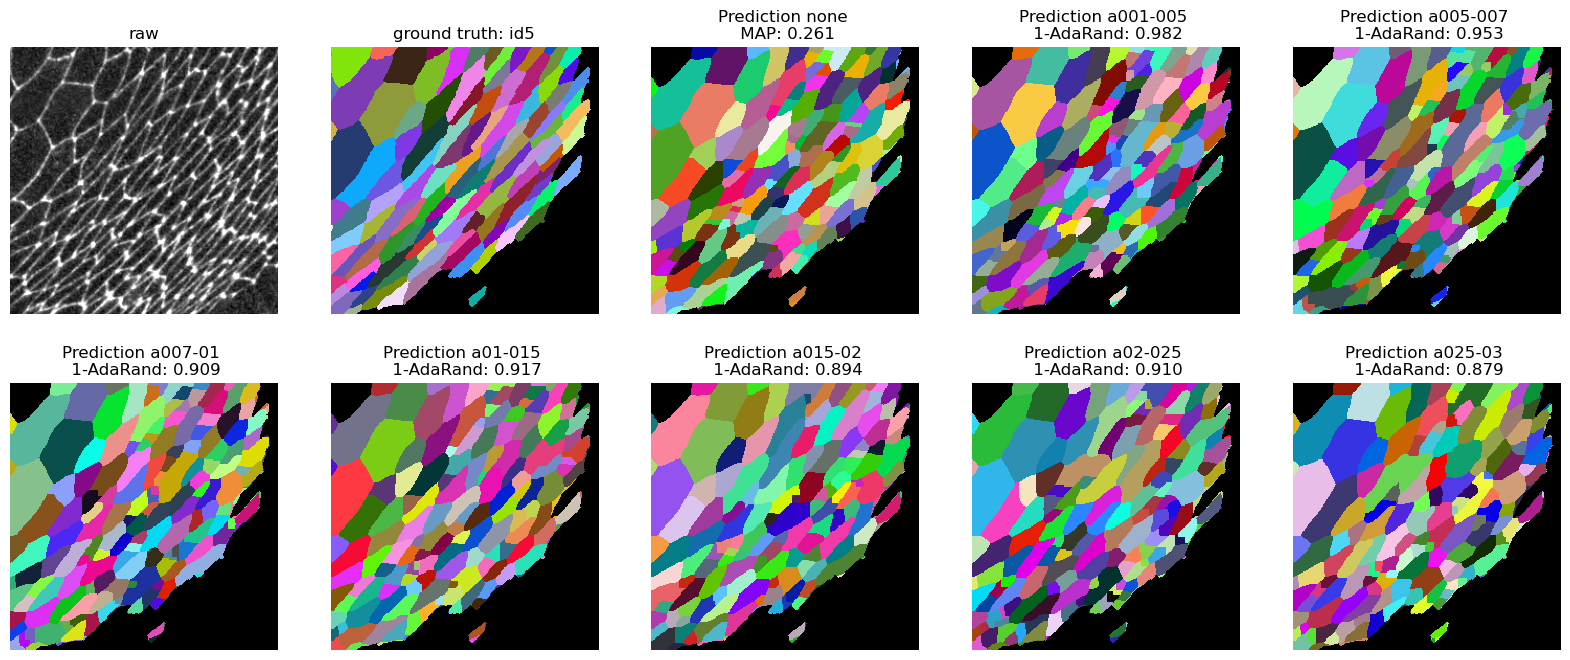

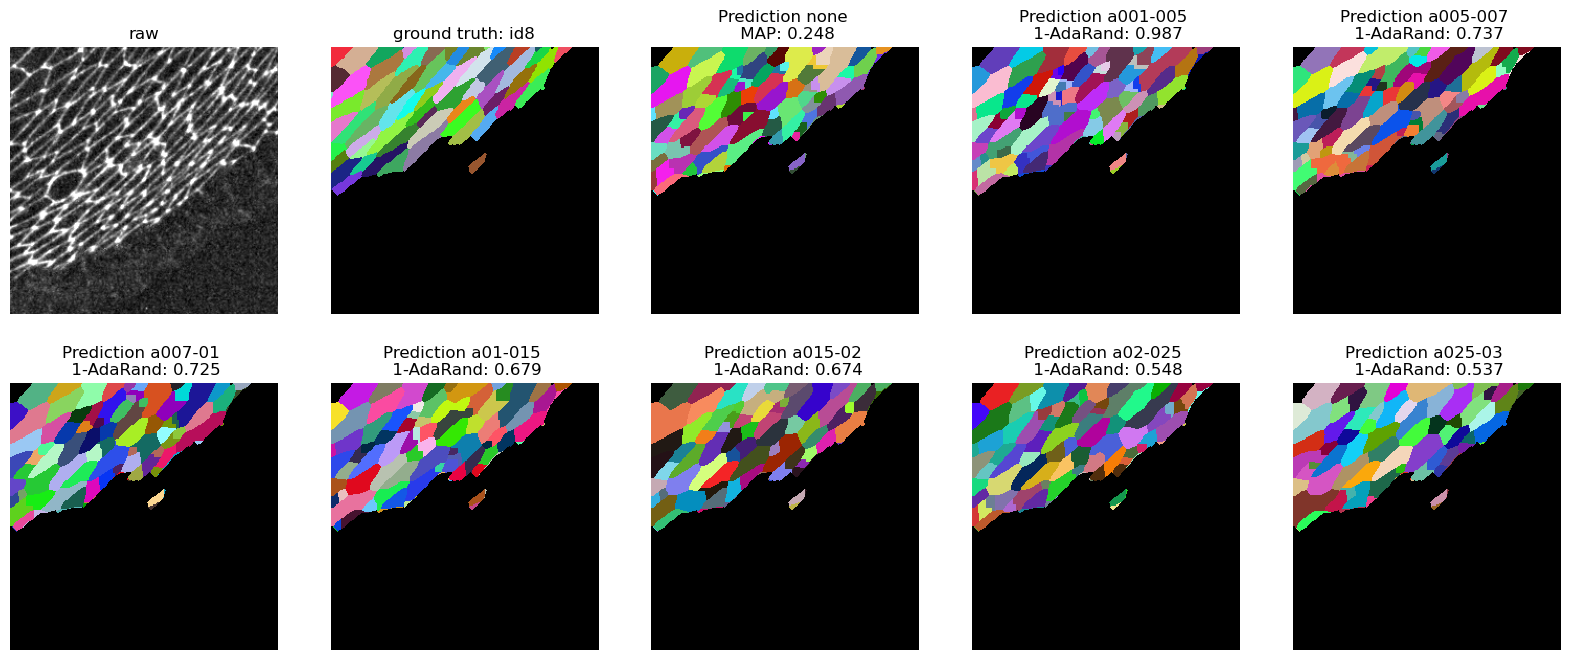

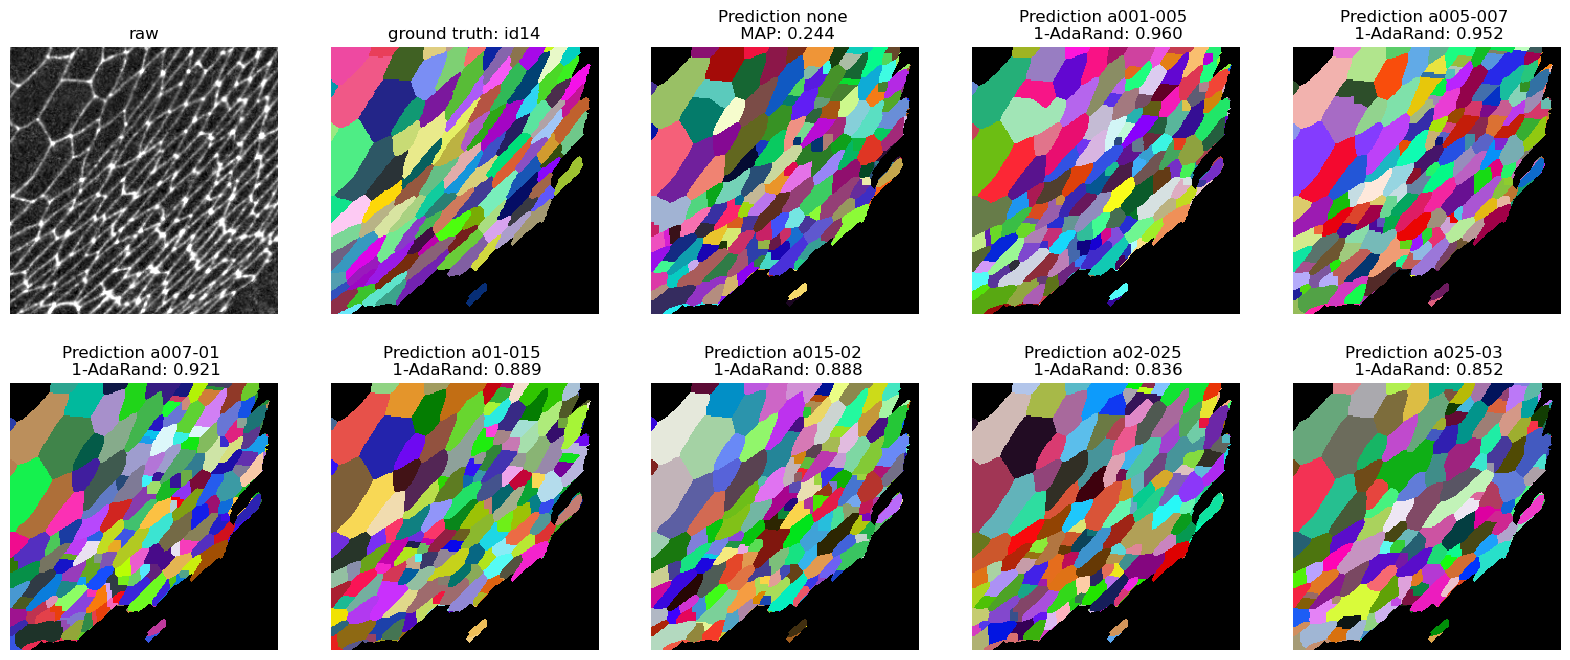

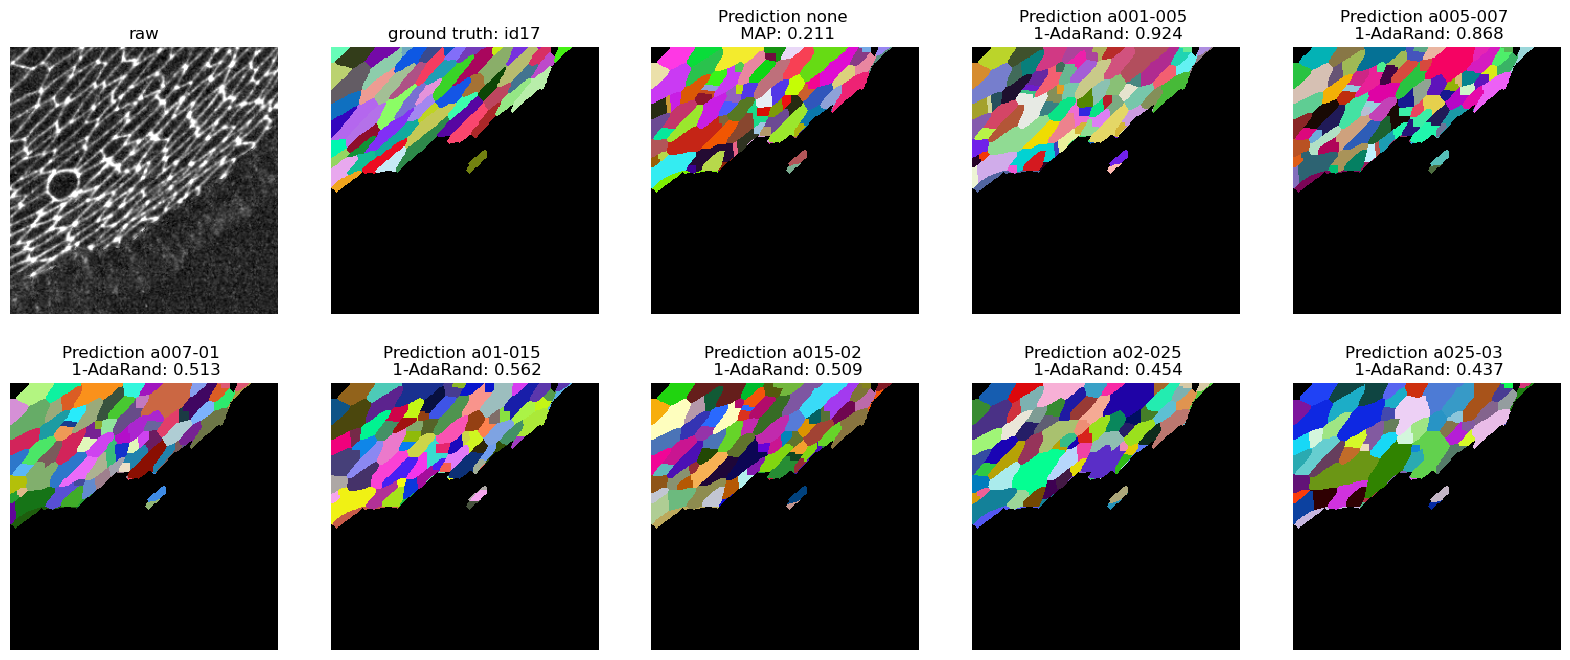

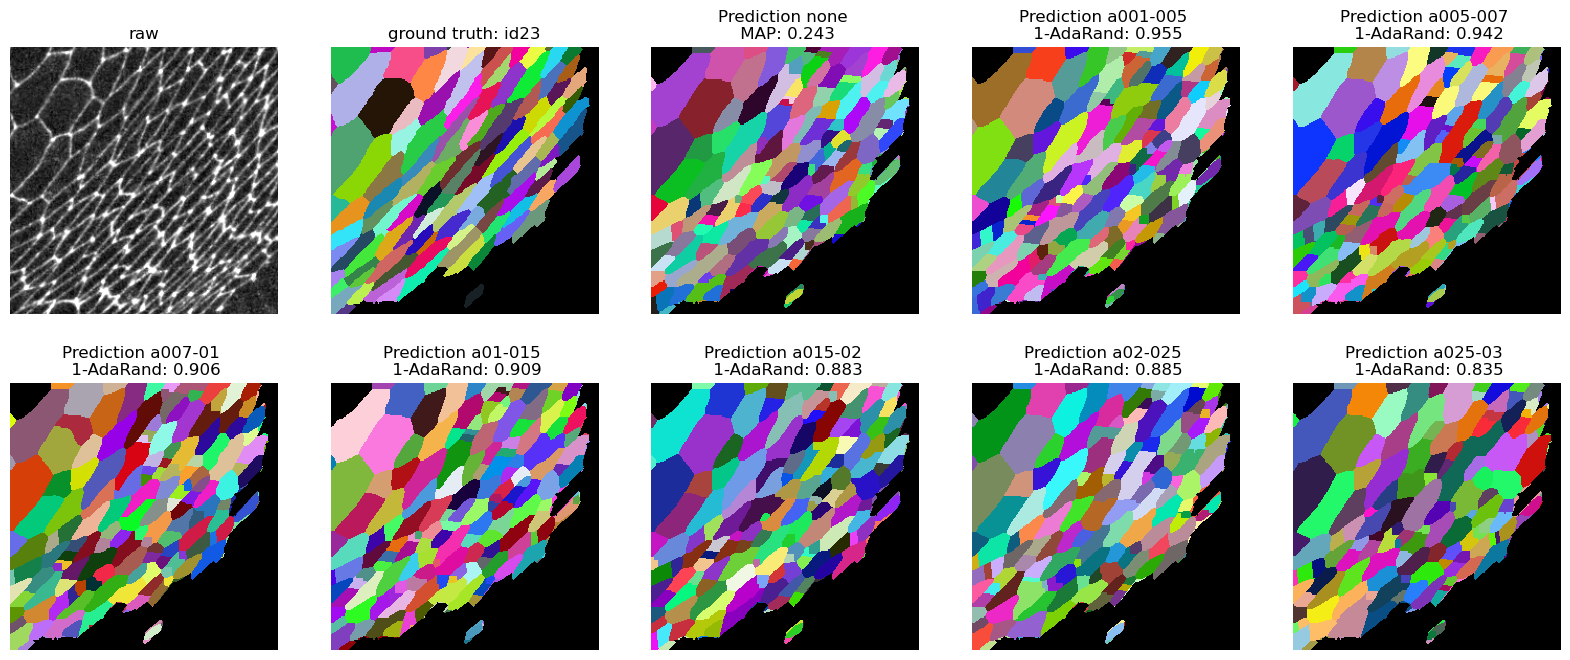

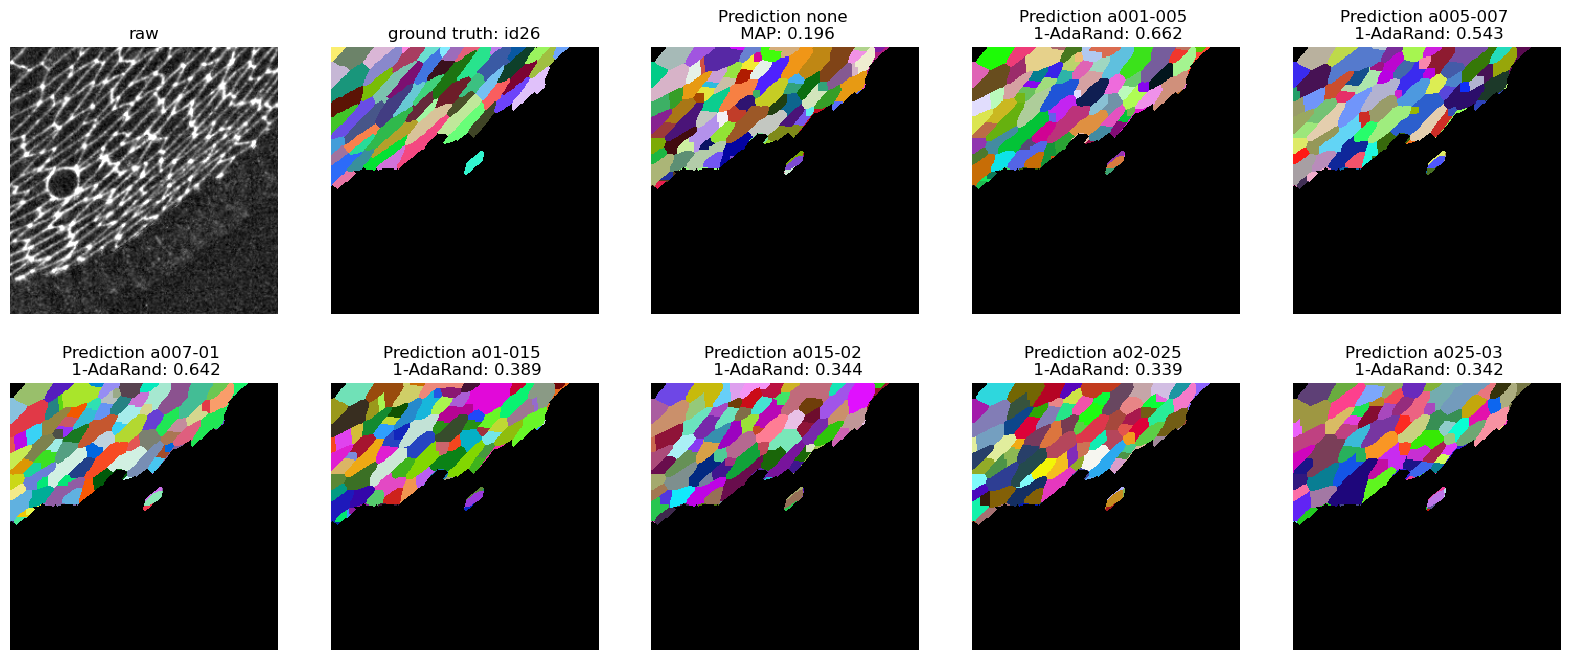

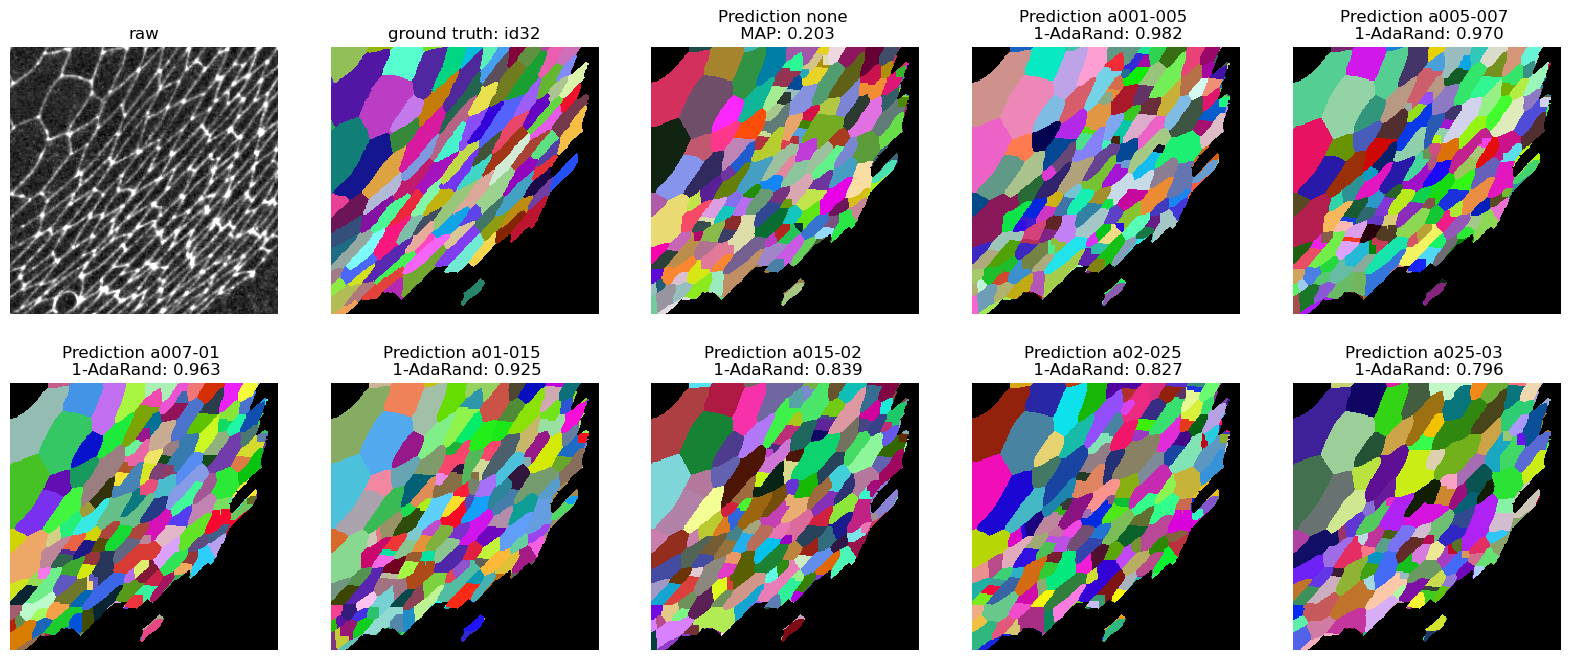

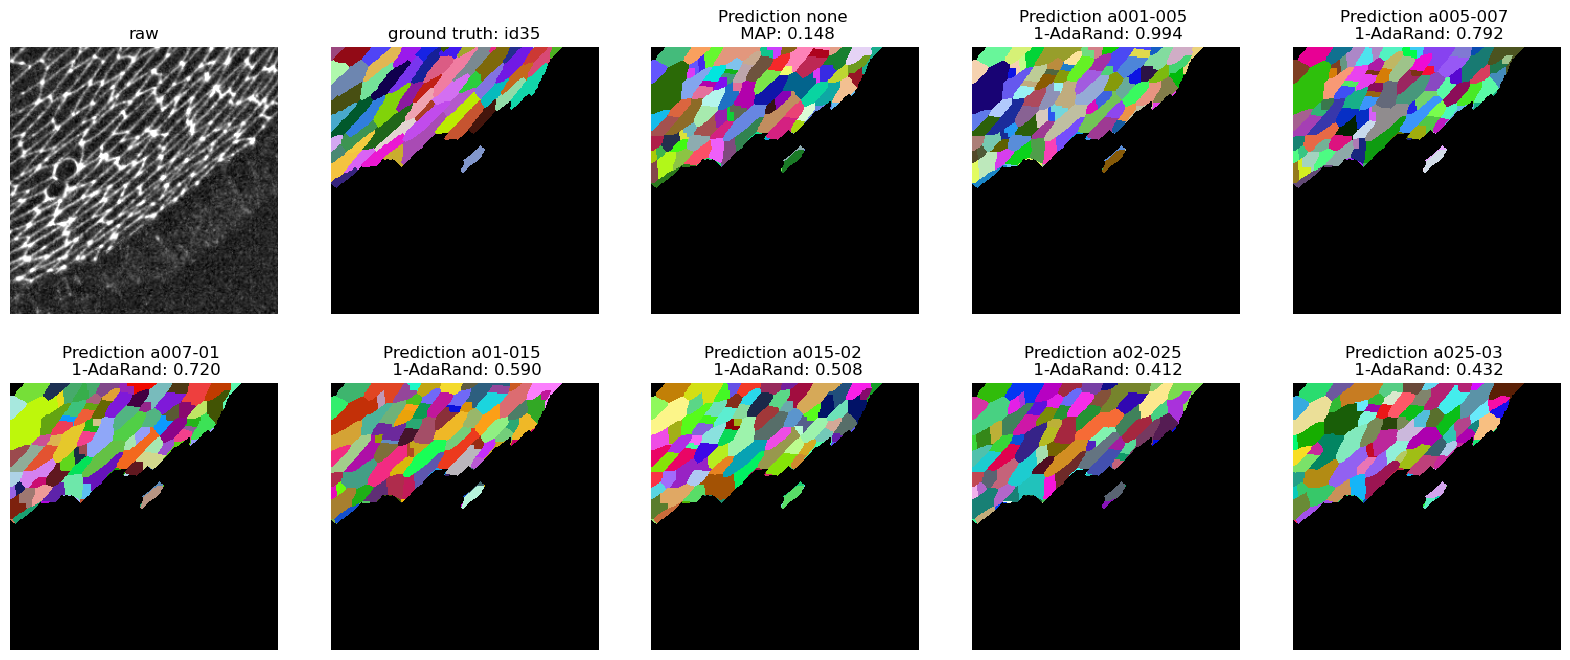

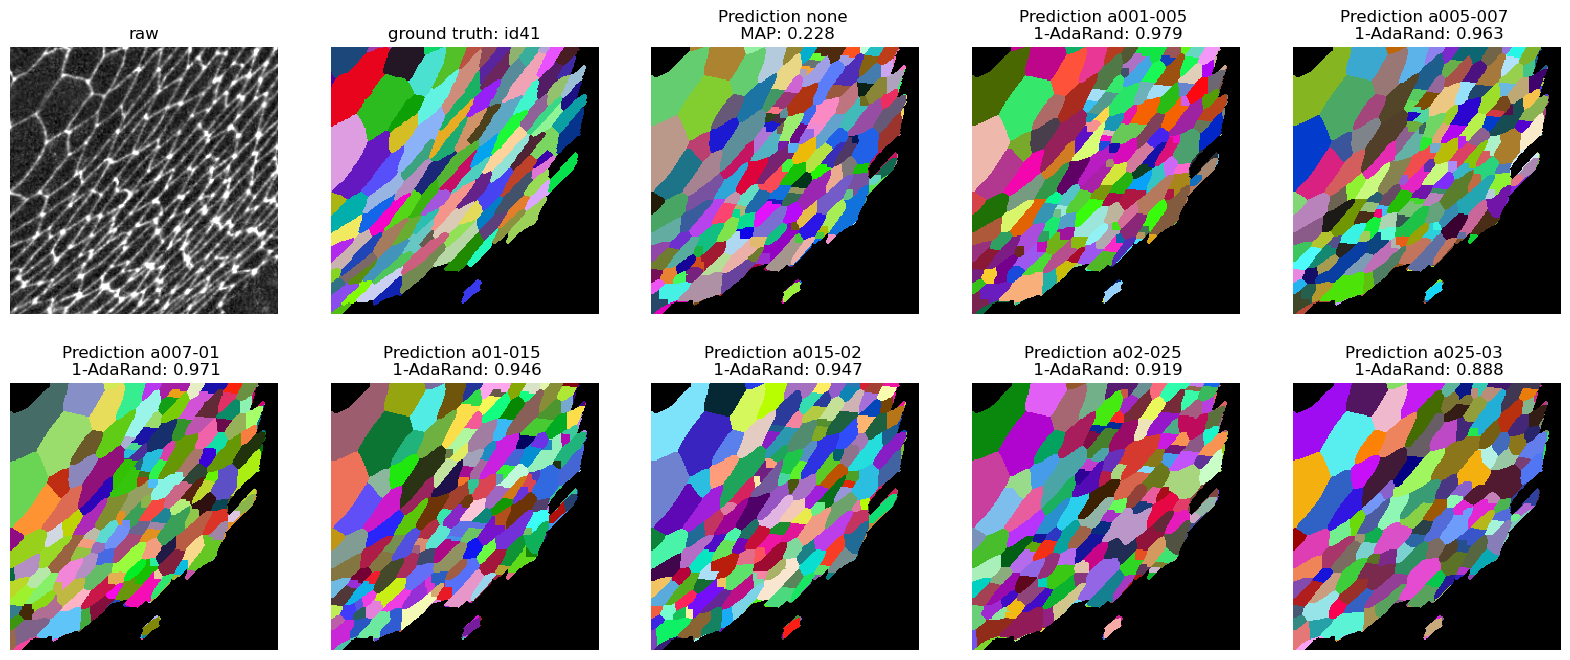

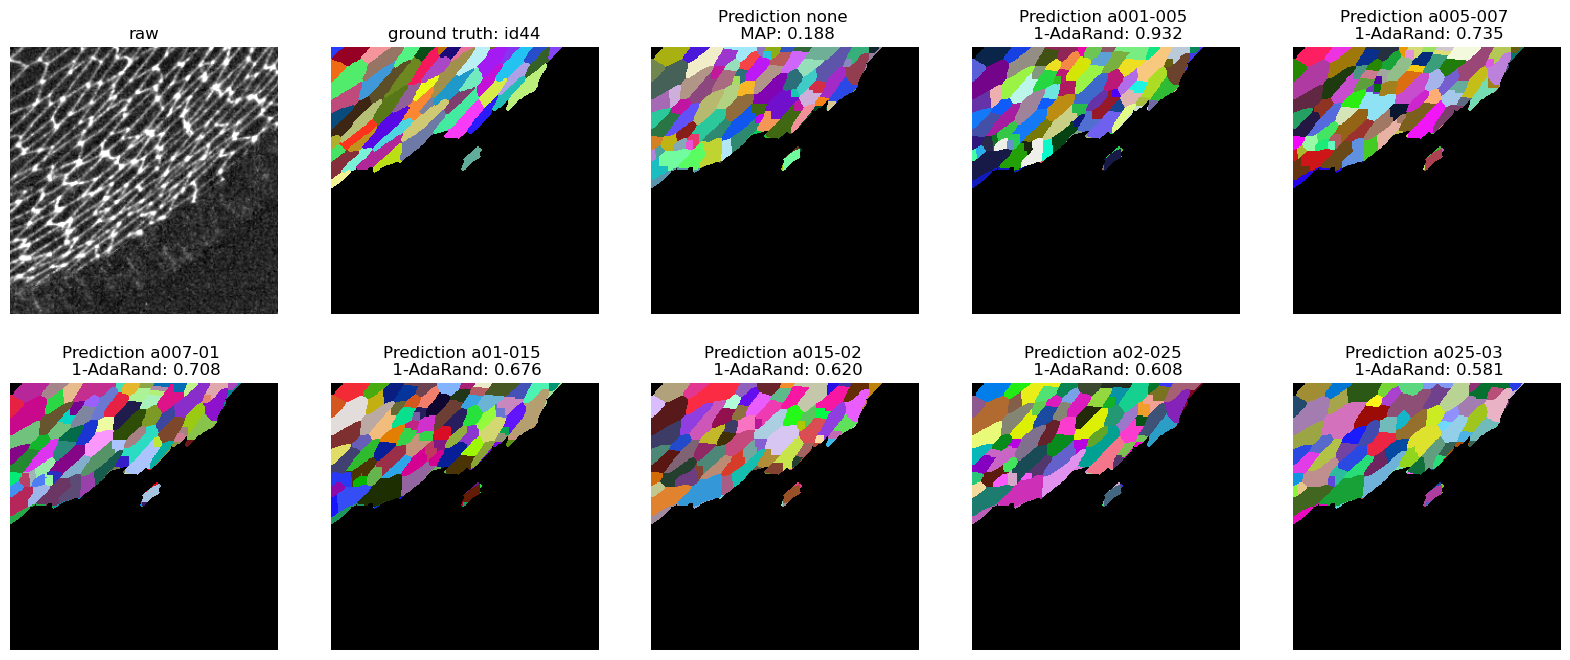

In [53]:
base_path = Path("/g/kreshuk/talks/consistency_results/Instance_segmentation/Cells/PNAS_to_FlyWing_gap/consistency/P_full2/p_model_NA1/norm_50_950")
paths = list(base_path.rglob("**/predictions/per03_predictions.h5"))
print(len(paths))
num_samples = 10
selected_augs = ["none", "a001-005", "a005-007", "a007-01", "a01-015", "a015-02", "a02-025", "a025-03"]

for i in ids_sub_03[:num_samples]:
    patch_roi = get_roi_slice(patch_indexes[i])
    raw = fw_raw[patch_roi].squeeze()
    label = fw_gt[patch_roi].squeeze()
    ignore_mask = label == -1
    label = Relabel(append_original = True, ignore_label=-1)(label)
    _, axs = plt.subplots(2,5, figsize=(20,8))
    axs = axs.flatten()
    axs[0].imshow(raw, cmap='gray')
    axs[0].set_title("raw")
    axs[0].axis('off')
    axs[1].imshow(label[0], cmap=get_random_colors(label[0]), interpolation='nearest')
    axs[1].set_title(f"ground truth: id{i}")
    axs[1].axis('off')
    # axs[2].imshow(load_h5(pred_path_NA, "segmentation", select_index=i).squeeze(), cmap='magma')
    # axs[2].set_title(f"Segmentation NA \n MAP: {MAP_score_NA[i]:.3f}")
    # axs[2].axis('off')
    for j, path in enumerate(paths):
        assert selected_augs[j] in str(path)
        preds_temp = load_h5(path, "segmentation", select_index=i).squeeze()
        preds_temp[ignore_mask] = 0
        axs[2+j].imshow(preds_temp.squeeze(), cmap=get_random_colors(preds_temp), interpolation='nearest')
        if "none" not in str(path):
            AdaRand_score = 1 - load_h5(path, "AdaRandError_consis", select_index=i)[0]
            axs[2+j].set_title(f"Prediction {selected_augs[j]} \n 1-AdaRand: {AdaRand_score:.3f}")
        else:
            axs[2+j].set_title(f"Prediction {selected_augs[j]} \n MAP: {MAP_scores[i]:.3f}")
        axs[2+j].axis('off')
    plt.show()

In [54]:
path = "/g/kreshuk/talks/consistency_results/Instance_segmentation/Cells/FlyWing_to_FlyWing_gap/consistency/P_full2/fw_model_Unet2/norm_50_950/none/predictions/per03_predictions.h5"
MAP_socres_NB = load_h5(path, "MAP_05_095")
print(np.median(MAP_socres_NB))
print(len(MAP_socres_NB))
MAP_scores_B = load_h5(path, "MAP_05_095_boundaries")
print(np.median(MAP_scores_B))
print(len(MAP_scores_B))

0.5974903
1440
0.58454293
1440


In [55]:
path = '/g/kreshuk/talks/consistency_results/Instance_segmentation/Cells/FlyWing_to_FlyWing_gap/consistency/P1/fw_model8/norm_5_95/none/metric_summary.h5'
MAP_score_med = load_h5(path, "MAP_05_095_median")
print(MAP_score_med)

0.8111928


In [56]:
path = "/g/kreshuk/talks/consistency_results/Instance_segmentation/Cells/FlyWing_to_FlyWing_gap/consistency/P_full2/fw_model8/norm_50_950/none/predictions/per03_predictions.h5"
MAP_scores = load_h5(path, "MAP_05_095")
print(np.median(MAP_scores))
print(len(MAP_scores))

0.59771836
1440


In [57]:
path = "/g/kreshuk/talks/consistency_results/Instance_segmentation/Cells/FlyWing_to_FlyWing_gap/consistency/fw_model_8_tests/fw_model8/norm_50_950/none/predictions/per03_predictions.h5"
MAP_scores = load_h5(path, "MAP_05_095")
print(np.median(MAP_scores))
print(len(MAP_scores))

0.8222792
1440


In [59]:
models = ['fw_model_Unet2', "fw_model_Res2", "fw_model8"]
beta_dirs = ['beta_05', 'beta_06', 'beta_07']

for beta in beta_dirs:
    print(f"Results for {beta}")
    for model in models:
        path = f"/g/kreshuk/talks/consistency_results/Instance_segmentation/Cells/FlyWing_to_FlyWing_gap/consistency/{beta}/{model}/norm_50_950/none/predictions/per03_predictions.h5"
        MAP_scores = load_h5(path, "MAP_05_095")
        print(f"{model}: {np.median(MAP_scores)}")

Results for beta_05
fw_model_Unet2: 0.8247804641723633
fw_model_Res2: 0.8238329887390137
fw_model8: 0.8231699466705322
Results for beta_06
fw_model_Unet2: 0.8233174085617065
fw_model_Res2: 0.8236097097396851
fw_model8: 0.8198610544204712
Results for beta_07
fw_model_Unet2: 0.7785695791244507
fw_model_Res2: 0.7870851159095764
fw_model8: 0.7752012014389038


In [61]:
models = ['ov_model_UNet1', "ov_model_Res1", "ov_model_NA1"]
beta_dirs = ['beta_05', 'beta_06', 'P_full2']

for beta in beta_dirs:
    print(f"Results for {beta}")
    for model in models:
        path = f"/g/kreshuk/talks/consistency_results/Instance_segmentation/Cells/Ovules_to_FlyWing_gap/consistency/{beta}/{model}/norm_50_950/none/predictions/per03_predictions.h5"
        MAP_scores = load_h5(path, "MAP_05_095")
        print(f"{model}: {np.median(MAP_scores)}")

Results for beta_05
ov_model_UNet1: 0.7300413846969604
ov_model_Res1: 0.0
ov_model_NA1: 0.006424181163311005
Results for beta_06
ov_model_UNet1: 0.7442451119422913
ov_model_Res1: 0.0
ov_model_NA1: 0.02432432398200035
Results for P_full2
ov_model_UNet1: 0.5737462043762207
ov_model_Res1: 0.012625208124518394
ov_model_NA1: 0.10010940581560135


In [62]:
models = ['p_model_UNet1', "p_model_Res1", "p_model_NA1"]
beta_dirs = ['beta_05', 'beta_06', 'P_full2']

for beta in beta_dirs:
    print(f"Results for {beta}")
    for model in models:
        path = f"/g/kreshuk/talks/consistency_results/Instance_segmentation/Cells/PNAS_to_FlyWing_gap/consistency/{beta}/{model}/norm_50_950/none/predictions/per03_predictions.h5"
        MAP_scores = load_h5(path, "MAP_05_095")
        print(f"{model}: {np.median(MAP_scores)}")

Results for beta_05
p_model_UNet1: 0.7461123466491699
p_model_Res1: 0.7492938041687012
p_model_NA1: 0.7486622333526611
Results for beta_06
p_model_UNet1: 0.7302581071853638
p_model_Res1: 0.7387486696243286
p_model_NA1: 0.7337634563446045
Results for P_full2
p_model_UNet1: 0.5451114177703857
p_model_Res1: 0.5511763095855713
p_model_NA1: 0.5470447540283203
